#Chile - Universidad Adolfo Ibáñez (UAI)
##Curso NLP
### Text Classification - Sentiment Analysis (Inglés)

# Carga & Exploración de Datos

In [1]:
#Importar Librerías
import pandas as pd
import numpy as np
import spacy

In [2]:
#Importar Archivos
df_train = pd.read_csv('/content/sentiment_analysis_train.csv', encoding='latin-1')
df_test = pd.read_csv('/content/sentiment_analysis_test.csv', encoding='latin-1')

In [3]:
#Verificar Columns
print("Train Dataset:", df_train.columns)

Train Dataset: Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')


In [4]:
#Verificar Tamaño
print("Tamaño Train Dataset:", df_train.shape)
print("Tamaño Test Dataset:", df_test.shape)

Tamaño Train Dataset: (5000, 6)
Tamaño Test Dataset: (1000, 6)


In [5]:
#Verificar Contenido
df_train.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,44062,89014,"Washington, DC",13/04/2020,???What's happening livestock futures prices f...,Positive
1,44734,89686,"Tallahassee, FL.",14/04/2020,Despite the current economic slowdown caused b...,Positive
2,31094,76046,Kinross,03/04/2020,The has forced the 44 year old staff member in...,Positive
3,19512,64464,United Kingdom,22/03/2020,Covid-19 is causing difficulties across the en...,Negative
4,9308,54260,NaN,19/03/2020,Incomprehensible In a Lidl supermarket in a cu...,Negative


In [6]:
#Verificar Distribución Label (Train)
print("Distribución Label (Train)")
print(df_train['Sentiment'].value_counts(normalize=True))

Distribución Label (Train)
Sentiment
Positive    0.4330
Negative    0.3722
Neutral     0.1948
Name: proportion, dtype: float64


In [7]:
#Verificar Distribución Label (Test)
print("Distribución Label (Test)")
print(df_test['Sentiment'].value_counts(normalize=True))

Distribución Label (Test)
Sentiment
Negative    0.449
Positive    0.404
Neutral     0.147
Name: proportion, dtype: float64


# Representación Vectorial

In [8]:
#Descargar spaCy pipeline
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 141.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
#Cargar Pipeline
nlp = spacy.load("en_core_web_sm")

In [10]:
#Obtener Doc Word Embeddings (Train)
doc_vectors_train = []
for tweet in df_train['OriginalTweet']:
  doc = nlp(tweet)
  doc_vectors_train.append(doc.vector)

In [11]:
#Obtener Doc Word Embeddings (Test)
doc_vectors_test = []
for tweet in df_test['OriginalTweet']:
  doc = nlp(tweet)
  doc_vectors_test.append(doc.vector)

In [12]:
#Generar Matriz X
X_train = np.array(doc_vectors_train)
X_test = np.array(doc_vectors_test)
print("Dimensionalidad X_train:", X_train.shape)
print("Dimensionalidad X_test:", X_test.shape)

Dimensionalidad X_train: (5000, 96)
Dimensionalidad X_test: (1000, 96)


# Train, Dev & Test Set

In [13]:
#Importar Librerías
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [14]:
#Listado Ordeneado de Clases
classes = ['Negative',
           'Neutral',
           'Positive']

In [15]:
#Crear & Ajustar Objeto LabelBinarizer
lb = LabelBinarizer()
lb.fit(df_train['Sentiment'])

LabelBinarizer()

In [16]:
#Creación Vector Labels
y_train = lb.transform(df_train['Sentiment'])
y_test = lb.transform(df_test['Sentiment'])

In [19]:
#Creación Train & Dev Set
dev_size = 0.1
X_train_dev, X_dev, y_train_dev, y_dev = train_test_split(X_train, y_train,
                                                          test_size=dev_size,
                                                          stratify=y_train,
                                                          random_state=0)

In [20]:
#Validar Tamaño Datasets
print('Train-Dev Set: X', X_train_dev.shape, '- Y: ',y_train_dev.shape)
print('Dev Set: X', X_dev.shape, '- Y: ',y_dev.shape)
print('Test Set: X', X_test.shape, '- Y: ',y_test.shape)

Train-Dev Set: X (4500, 96) - Y:  (4500, 3)
Dev Set: X (500, 96) - Y:  (500, 3)
Test Set: X (1000, 96) - Y:  (1000, 3)


In [21]:
#Guardar Dimensiones de la Rep. Vectorial
input_dim = X_train_dev.shape[1]

# FNN (2 Layers) - Sin HP

In [23]:
#Importar Librerías
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import f1_score

In [24]:
#Creación & Configuración Objeto Sequential

#Inicializar Modelo
model_ann_2l = Sequential()

#Primera Capa Oculta
model_ann_2l.add(Dense(96, input_dim=input_dim, activation='relu'))

#Segunda Capa Oculta
model_ann_2l.add(Dense(96, activation='relu'))

#Capa Salida
model_ann_2l.add(Dense(3, activation='softmax'))

#Compilación
model_ann_2l.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_ann_2l.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,915 (73.89 KB)

 Trainable params: 18,915 (73.89 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#Entrenar ANN
history_ann_2l = model_ann_2l.fit(X_train, y_train,
                                  epochs=20,
                                  validation_split=0.2,
                                  batch_size=5)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4120 - loss: 1.0485 - val_accuracy: 0.4970 - val_loss: 0.9969
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4823 - loss: 0.9981 - val_accuracy: 0.4890 - val_loss: 0.9765
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5160 - loss: 0.9482 - val_accuracy: 0.4830 - val_loss: 0.9752
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5331 - loss: 0.9353 - val_accuracy: 0.4810 - val_loss: 0.9689
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5876 - loss: 0.8867 - val_accuracy: 0.4920 - val_loss: 0.9751
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5884 - loss: 0.8605 - val_accuracy: 0.4920 - val_loss: 1.0464
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6214 - loss: 0.8062 - val_accuracy: 0.4770 - val_loss: 1.0245
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6531 - loss: 0.7780 - val_accuracy: 0.

In [26]:
#Gráfico Accuracy & Loss (Training & Validation)

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

def plot_accuracy_loss(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training Accuracy')
    plt.plot(x, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training Loss')
    plt.plot(x, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

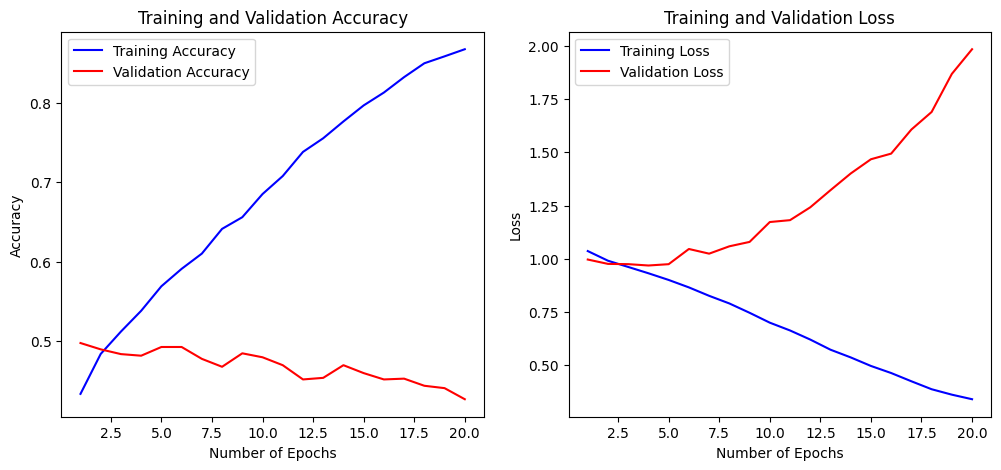

In [27]:
#Revisar Accuracy & Loss
plot_accuracy_loss(history_ann_2l)

In [28]:
#Umbral de Predicción
threshold = 0.5

In [29]:
#Evaluar ANN
y_pred_ann_2l = model_ann_2l.predict(X_test) > threshold

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [34]:
#Evaluación
print('F1 Score (Ponderado):', round(f1_score(y_test, y_pred_ann_2l, average='weighted'),3))
print('F1 Score (Label):', f1_score(y_test, y_pred_ann_2l, average=None))

F1 Score (Ponderado): 0.428
F1 Score (Label): [0.48720801 0.31578947 0.40401146]


# FNN (2 Layers) - Con HP

In [35]:
#Instalar e Importar Keras Turner
!pip install keras-tuner -q
import keras_tuner as kt
from keras.backend import clear_session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 11.3 MB/s eta 0:00:00


In [36]:
# Función para Creación Modelo

def ann_2l_model(hp):

  clear_session()

  #Inicializar Modelo
  model = Sequential()

  #HP para Función Activación
  hp_activation_function = hp.Choice('activation', values=['relu', 'tanh'])

  # HP para Cantidad de Nodos en Capas Ocultas
  hp_units = hp.Int('units', min_value=80, max_value=120, step=10)

  #Primera Capa Oculta
  model.add(Dense(hp_units, input_dim=input_dim, activation=hp_activation_function))

  #Segunda Capa Oculta
  model.add(Dense(hp_units, activation=hp_activation_function))

  #Capa Salida
  model.add(Dense(3, activation='softmax'))

  #Model Compilation
  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [37]:
#Inicializar Objeto Keras Turner
tuner = kt.BayesianOptimization(hypermodel=ann_2l_model,
                                objective=kt.Objective('val_accuracy', direction='max'),
                                max_trials=8,
                                overwrite=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
#Revisar Espacio de Búsqueda
tuner.search_space_summary()

Search space summary
Default search space size: 2
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
units (Int)
{'default': None, 'conditions': [], 'min_value': 80, 'max_value': 120, 'step': 10, 'sampling': 'linear'}


In [39]:
#Encontrar HP
tuner.search(X_train_dev, y_train_dev,
             epochs=10,
             validation_data=(X_dev, y_dev))

Trial 8 Complete [00h 00m 09s]
val_accuracy: 0.5139999985694885

Best val_accuracy So Far: 0.515999972820282
Total elapsed time: 00h 01m 14s


In [41]:
#Mejores HP
best_ann_2l_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores HP", best_ann_2l_hp.values)

Mejores HP {'activation': 'relu', 'units': 80}


In [42]:
#Construir Modelo con Mejores HP
hp_model_ann_2l = tuner.hypermodel.build(best_ann_2l_hp)
hp_model_ann_2l.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 80)             │         7,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           243 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,483 (56.57 KB)

 Trainable params: 14,483 (56.57 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
#Compilación
hp_model_ann_2l.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [44]:
#Entrenar ANN
history_hp_ann_2l = hp_model_ann_2l.fit(X_train, y_train,
                                        epochs=20,
                                        validation_split=0.2,
                                        batch_size=5)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4313 - loss: 1.0509 - val_accuracy: 0.4930 - val_loss: 0.9851
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4831 - loss: 0.9931 - val_accuracy: 0.4920 - val_loss: 0.9721
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5188 - loss: 0.9641 - val_accuracy: 0.4800 - val_loss: 0.9759
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5368 - loss: 0.9318 - val_accuracy: 0.4840 - val_loss: 0.9733
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5507 - loss: 0.9026 - val_accuracy: 0.5090 - val_loss: 0.9766
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5813 - loss: 0.8883 - val_accuracy: 0.4860 - val_loss: 1.0194
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6261 - loss: 0.8203 - val_accuracy: 0.4860 - val_loss: 1.0029
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6310 - loss: 0.7968 - val_accuracy: 0.

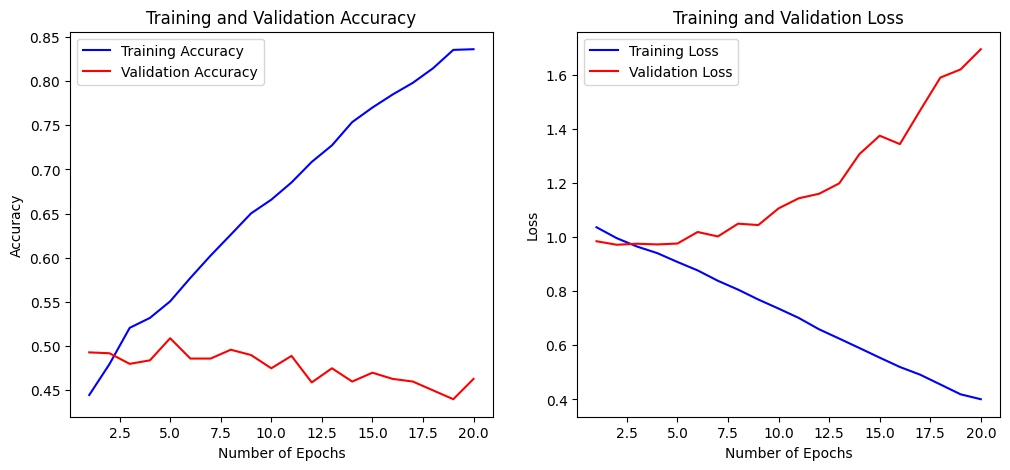

In [45]:
#Revisar Accuracy & Loss
plot_accuracy_loss(history_hp_ann_2l)

In [46]:
#Evaluar ANN
y_pred_hp_ann_2l = hp_model_ann_2l.predict(X_test) > threshold
print('F1 Score (Ponderado):', round(f1_score(y_test, y_pred_hp_ann_2l, average="weighted"),3))
print('F1 Score (Por Clase):', f1_score(y_test, y_pred_hp_ann_2l, average=None))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
F1 Score (Ponderado): 0.437
F1 Score (Por Clase): [0.40641711 0.3236246  0.51194539]
